In [1]:
# Figure 5: revised model of ATFS-1 regulon composition and occupancy. Not a new
# analysis - a conceptual schematic contrasting the field's prior expectation
# against what Figures 1 and 2 already established with real data. The only
# numbers drawn here (28/19/8/4/2 of 61) are read from results/, the same file
# figure_1.ipynb reads for its own composition bar, so the two figures cannot
# silently drift apart.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from figure_style import BLUE, ORANGE, GREEN, GREY, INK, FULL_W, save

regulon = pd.read_csv("results/regulon_61.csv")
if len(regulon) != 61:
    raise RuntimeError(f"results/regulon_61.csv has {len(regulon)} rows, expected 61.")

CATEGORY_ORDER = ["Other annotated function", "Uncharacterised (no GO annotation)",
                  "Xenobiotic detoxification", "Innate immunity", "Folding/QC (census)"]
CATEGORY_COLOR = {
    "Other annotated function": "#DDDDDD",
    "Uncharacterised (no GO annotation)": "#9E9E9E",
    "Xenobiotic detoxification": ORANGE,
    "Innate immunity": GREEN,
    "Folding/QC (census)": BLUE,
}
counts = regulon["category"].value_counts().reindex(CATEGORY_ORDER)
if counts.isna().any() or int(counts.sum()) != 61:
    raise RuntimeError(f"Category counts changed or incomplete: {counts.to_dict()}")
counts = counts.astype(int)
n_folding = int(counts["Folding/QC (census)"])
if n_folding != 2:
    raise RuntimeError(f"Folding/QC count changed: {n_folding}, expected 2 - Claim 1 headline moved.")
print("Composition counts (matches figure_1.ipynb's Panel C exactly):")
print(counts.to_string())

Composition counts (matches figure_1.ipynb's Panel C exactly):
category
Other annotated function              28
Uncharacterised (no GO annotation)    19
Xenobiotic detoxification              8
Innate immunity                        4
Folding/QC (census)                    2


Saved figures/figure5_revised_model.{pdf,svg,png}


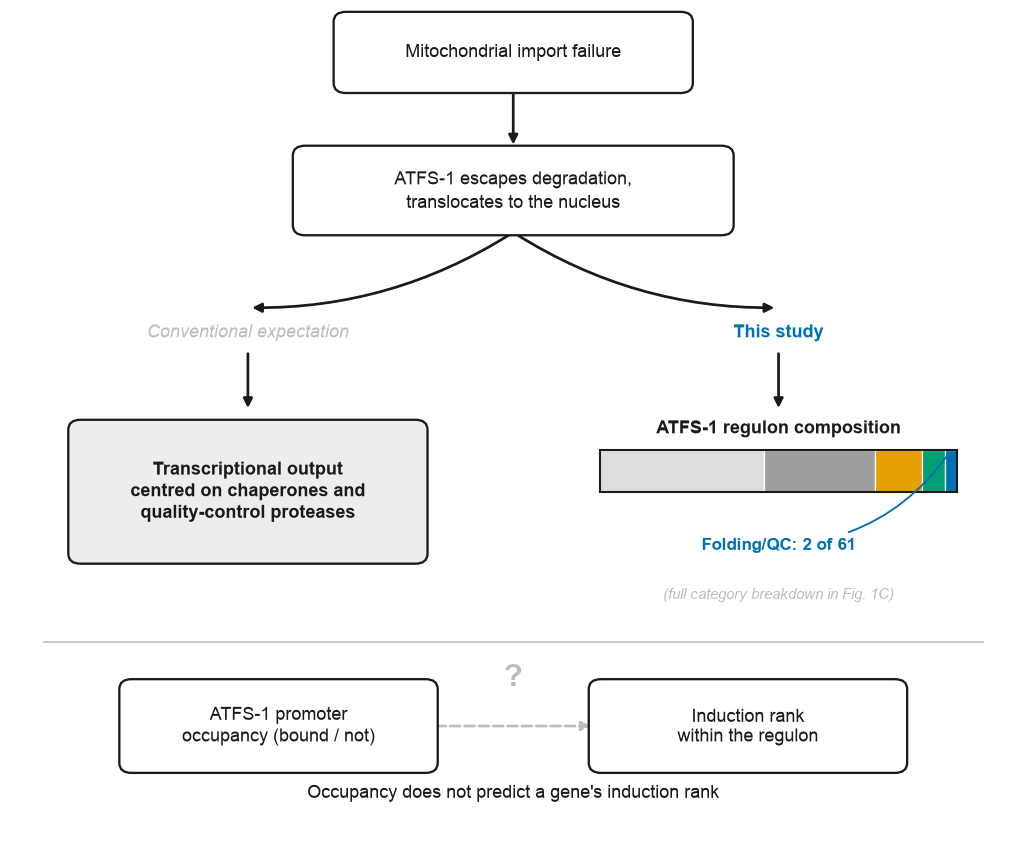

In [2]:
# Draw. A single wide panel, no A/B/C letters - the spec calls for one schematic,
# not a multi-panel figure. Layout: a shared trunk (import failure -> ATFS-1
# translocation, true under both models) forks into two contrasted outcomes -
# left, the field's prior expectation; right, what this study actually finds
# (Fig. 1C's composition, reproduced here at the real proportions rather than
# sketched) - plus a second, separate element below showing the Fig. 2 finding
# that occupancy does not predict induction rank.
#
# First pass here included a 5-item colour legend under the composition bar; the
# rendered image (not just the code running) showed it overlapping both the
# section divider and the boxes below it - fixed by dropping the legend (Fig. 1C
# is already the reference for the full category breakdown) and keeping only the
# one callout this panel's own point needs: how small the folding/QC slice is.
fig = plt.figure(figsize=(FULL_W, FULL_W * 0.82))
ax = fig.add_axes([0.02, 0.02, 0.96, 0.96])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def box(x, y, w, h, text, facecolor, textcolor=INK, fontsize=8.5, fontweight="normal", edgecolor=INK):
    patch = mpatches.FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.006,rounding_size=0.012",
        facecolor=facecolor, edgecolor=edgecolor, linewidth=1.1, zorder=2)
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
             fontweight=fontweight, color=textcolor, zorder=3, linespacing=1.3)

def arrow(xy_from, xy_to, style="solid", color=INK, lw=1.3, connectionstyle="arc3,rad=0.0"):
    ax.annotate("", xy=xy_to, xytext=xy_from,
                 arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                  linestyle=style, connectionstyle=connectionstyle,
                                  shrinkA=2, shrinkB=2), zorder=1)

# --- Shared trunk ---
box(0.5, 0.94, 0.34, 0.085, "Mitochondrial import failure", "white")
arrow((0.5, 0.895), (0.5, 0.825))
box(0.5, 0.775, 0.42, 0.095,
    "ATFS-1 escapes degradation,\ntranslocates to the nucleus", "white")

# Fork
arrow((0.5, 0.725), (0.24, 0.635), connectionstyle="arc3,rad=-0.15")
arrow((0.5, 0.725), (0.76, 0.635), connectionstyle="arc3,rad=0.15")

# --- Left branch: conventional expectation ---
ax.text(0.24, 0.615, "Conventional expectation", ha="center", va="top",
         fontsize=8.5, fontstyle="italic", color=GREY)
arrow((0.24, 0.585), (0.24, 0.51))
box(0.24, 0.415, 0.34, 0.16,
    "Transcriptional output\ncentred on chaperones and\nquality-control proteases",
    facecolor="#EDEDED", fontweight="bold")

# --- Right branch: this study ---
ax.text(0.76, 0.615, "This study", ha="center", va="top",
         fontsize=8.5, fontweight="bold", color=BLUE)
arrow((0.76, 0.585), (0.76, 0.51))

bar_left, bar_right, bar_y, bar_h = 0.585, 0.935, 0.44, 0.05
bar_w = bar_right - bar_left
x0 = bar_left
for cat in CATEGORY_ORDER:
    seg_w = counts[cat] / 61 * bar_w
    ax.add_patch(mpatches.Rectangle((x0, bar_y - bar_h / 2), seg_w, bar_h,
                                     facecolor=CATEGORY_COLOR[cat], edgecolor="white",
                                     linewidth=0.6, zorder=2))
    x0 += seg_w
ax.add_patch(mpatches.Rectangle((bar_left, bar_y - bar_h / 2), bar_w, bar_h,
                                 facecolor="none", edgecolor=INK, linewidth=1.0, zorder=3))
ax.text(0.76, 0.48, "ATFS-1 regulon composition", ha="center", va="bottom",
         fontsize=8.5, fontweight="bold", color=INK)

# Point at the folding/QC sliver specifically - it is too small to label in place.
# No per-category legend here: the full breakdown is Fig. 1C's job, this panel
# only needs the reader to see that the highlighted slice is small.
fold_x0 = bar_left + (61 - n_folding) / 61 * bar_w
fold_xc = fold_x0 + (n_folding / 61 * bar_w) / 2
ax.annotate(f"Folding/QC: {n_folding} of 61", xy=(fold_xc, bar_y + bar_h / 2),
             xytext=(0.76, 0.36), ha="center", va="top", fontsize=8, color=BLUE,
             fontweight="bold",
             arrowprops=dict(arrowstyle="-", color=BLUE, lw=0.9,
                              connectionstyle="arc3,rad=0.25"))
ax.text(0.76, 0.30, "(full category breakdown in Fig. 1C)", ha="center", va="top",
         fontsize=7, fontstyle="italic", color=GREY)

# --- Divider ---
ax.plot([0.04, 0.96], [0.235, 0.235], color=GREY, lw=0.8, zorder=1)

# --- Second finding: occupancy does not predict induction rank (Fig. 2) ---
box(0.27, 0.135, 0.30, 0.10, "ATFS-1 promoter\noccupancy (bound / not)", "white")
box(0.73, 0.135, 0.30, 0.10, "Induction rank\nwithin the regulon", "white")
arrow((0.42, 0.135), (0.58, 0.135), style="dashed", color=GREY, lw=1.3)
ax.text(0.5, 0.175, "?", ha="center", va="bottom", fontsize=15, fontweight="bold", color=GREY)
ax.text(0.5, 0.065, "Occupancy does not predict a gene's induction rank",
         ha="center", va="top", fontsize=8.5, color=INK)

save(fig, "figure5_revised_model")
plt.show()